In [10]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Gold futures (GC=F), Silver (SI=F), Copper (HG=F)
gold = yf.download("GC=F", interval="5m", period="60d")
silver = yf.download("SI=F", interval="5m", period="60d")
copper = yf.download("HG=F", interval="5m", period="60d")

gold.index   = gold.index.tz_convert("America/New_York")
silver.index = silver.index.tz_convert("America/New_York")
copper.index = copper.index.tz_convert("America/New_York")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


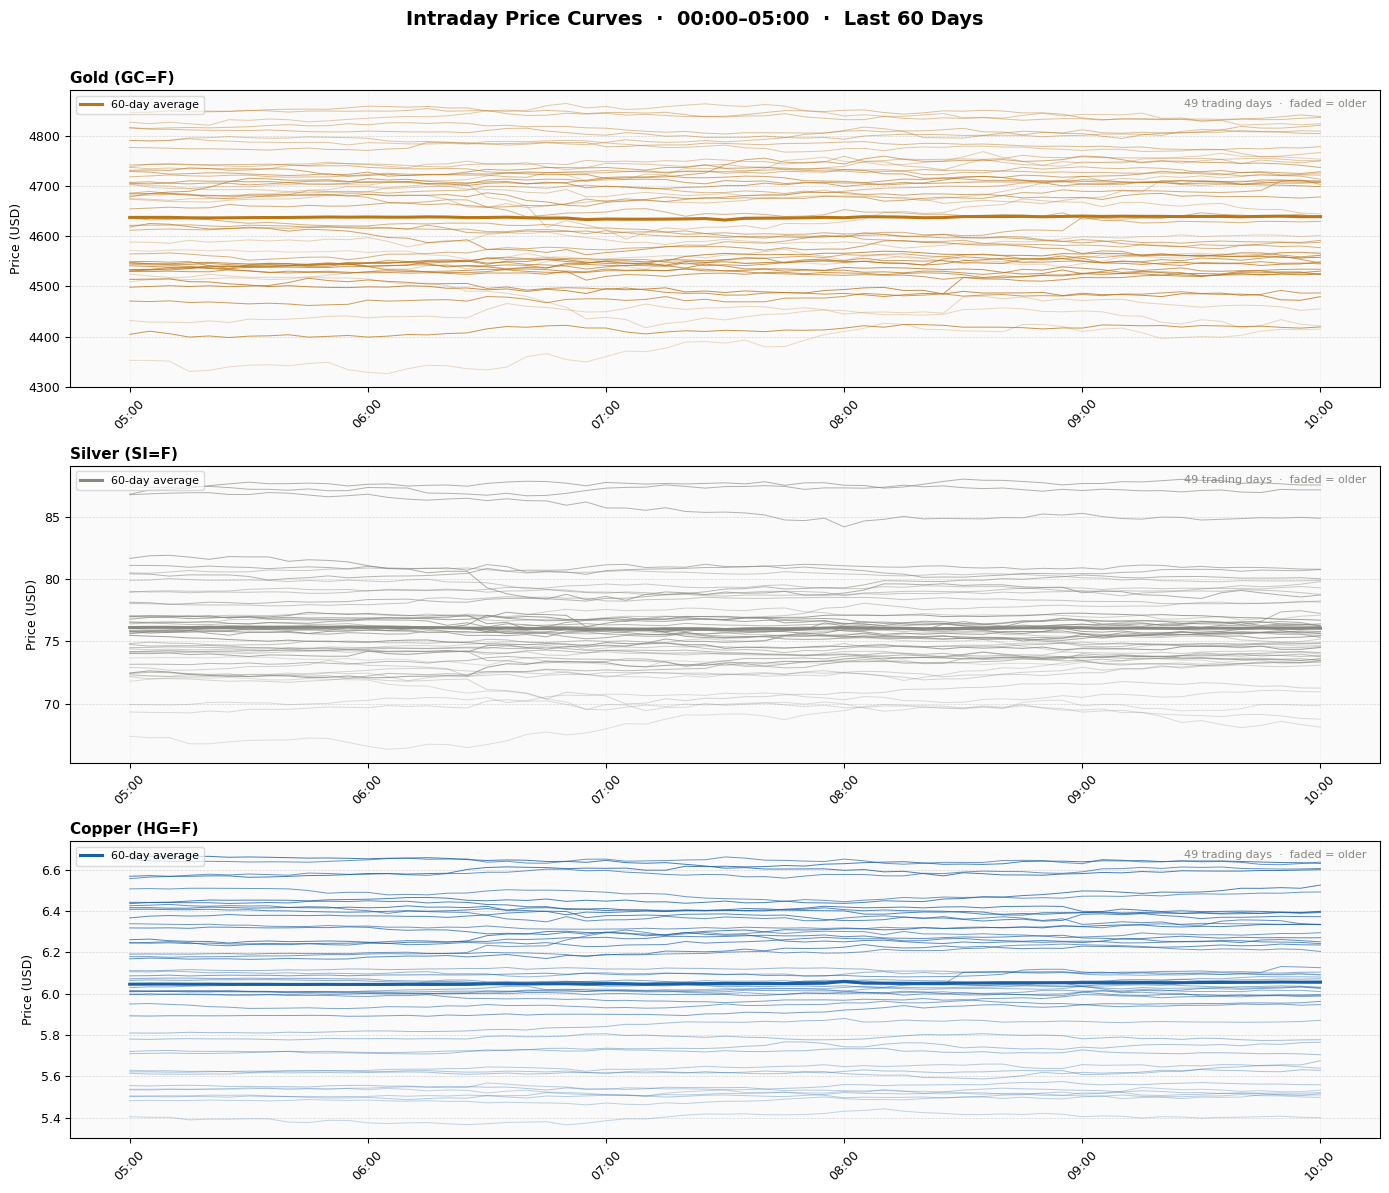

Saved: metals_intraday.png


In [11]:
# --- Config ---
metals = {
    "Gold":   (gold,   "#BA7517"),
    "Silver": (silver, "#888780"),
    "Copper": (copper, "#185FA5"),
}
 
SESSION_START = "00:00"
SESSION_END   = "05:00"
 
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Intraday Price Curves  ·  00:00–05:00  ·  Last 60 Days",
             fontsize=14, fontweight="bold", y=0.99)
 
for ax, (name, (df, color)) in zip(axes, metals.items()):
 
    # flatten MultiIndex columns if present
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
 
    # filter to session window
    df.index = pd.to_datetime(df.index)
    session = df.between_time(SESSION_START, SESSION_END)
 
    if session.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
        continue
 
    # group by date and plot each day as one line
    dates = session.index.normalize().unique()
    for i, day in enumerate(dates):
        day_data = session[session.index.normalize() == day]["Close"].dropna()
        if len(day_data) < 2:
            continue
 
        # convert timestamps to a common "time-of-day" float for x-axis alignment
        times = [t.replace(year=2000, month=1, day=1) for t in day_data.index]
 
        alpha = 0.25 + 0.55 * (i / max(len(dates) - 1, 1))   # older = more faded
        ax.plot(times, day_data.values,
                color=color, linewidth=0.7, alpha=alpha)
 
    # x-axis: time labels
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
 
    # set x limits explicitly to session window
    import datetime
    # xmin = datetime.datetime(2000, 1, 1, 9,  0)
    # xmax = datetime.datetime(2000, 1, 1, 17, 0)
    # ax.set_xlim(xmin, xmax)
 
    ax.set_title(f"{name} (GC=F)" if name == "Gold" else
                 f"{name} (SI=F)" if name == "Silver" else
                 f"{name} (HG=F)",
                 fontsize=11, fontweight="bold", loc="left", pad=5)
    ax.set_ylabel("Price (USD)", fontsize=9)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.grid(axis="x", linestyle=":",  linewidth=0.4, alpha=0.4)
    ax.set_facecolor("#fafafa")
 
    # --- average line across all days at each time-of-day ---
    # normalise index to a single reference date so times align across days
    session_norm = session["Close"].copy()
    session_norm.index = session_norm.index.map(
        lambda t: t.replace(year=2000, month=1, day=1)
    )
    avg = session_norm.groupby(session_norm.index).mean().dropna()
    ax.plot(avg.index, avg.values,
            color=color, linewidth=2.2, alpha=1.0,
            linestyle="-", zorder=10, label="60-day average")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.7)
 
    # legend note
    ax.text(0.99, 0.97,
            f"{len(dates)} trading days  ·  faded = older",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="#888780")
 
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("metals_intraday.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metals_intraday.png")


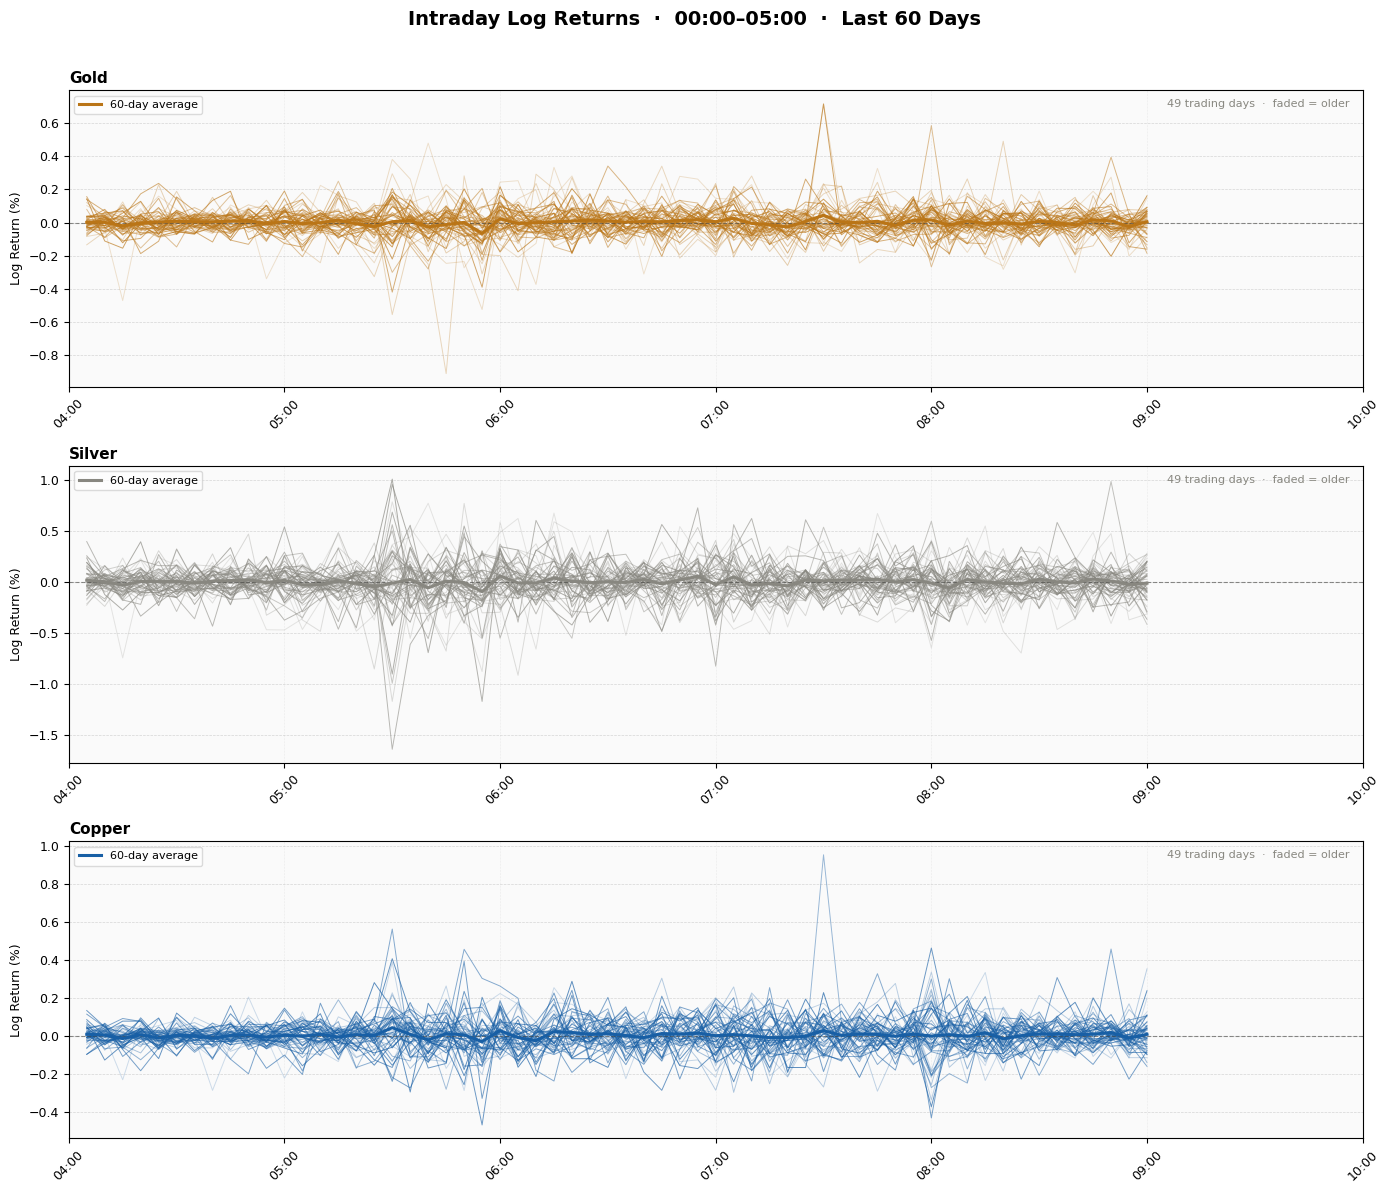

Saved: metals_intraday_logreturns.png


In [12]:
REF_DATE      = datetime.datetime(2026, 6, 3)
 
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Intraday Log Returns  ·  00:00–05:00  ·  Last 60 Days",
             fontsize=14, fontweight="bold", y=0.99)
 
for ax, (name, (df, color)) in zip(axes, metals.items()):
 
    # flatten MultiIndex columns if present
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df.index = pd.to_datetime(df.index)
 
    # filter to session window
    session = df.between_time(SESSION_START, SESSION_END)[["Close"]].copy()
    if session.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
        continue
 
    # compute log returns within each day
    # first bar of each day is NaN (no previous price) — drop it
    session["log_ret"] = (
        np.log(session["Close"])
        .groupby(session.index.normalize())
        .diff()
    )
    session = session.dropna(subset=["log_ret"])
 
    dates = session.index.normalize().unique()
 
    # --- plot individual day curves ---
    for i, day in enumerate(dates):
        day_data = session[session.index.normalize() == day]["log_ret"]
        if len(day_data) < 2:
            continue
        times = [t.replace(year=2026, month=6, day=3) for t in day_data.index]
        alpha = 0.20 + 0.50 * (i / max(len(dates) - 1, 1))
        ax.plot(times, day_data.values * 100,       # express as %
                color=color, linewidth=0.7, alpha=alpha)
 
    # --- average log return at each intraday time slot ---
    norm_idx = session.index.map(lambda t: t.replace(year=2026, month=6, day=3))
    avg = (session["log_ret"] * 100).groupby(norm_idx).mean().dropna()
    ax.plot(avg.index, avg.values,
            color=color, linewidth=2.2, alpha=1.0,
            linestyle="-", zorder=10, label="60-day average")
 
    # zero reference line
    ax.axhline(0, color="#444441", linewidth=0.8, linestyle="--", alpha=0.6)
 
    # x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
 
    xmin = REF_DATE.replace(hour=4,  minute=0)
    xmax = REF_DATE.replace(hour=10, minute=0)
    ax.set_xlim(xmin, xmax)
 
    ax.set_title(name, fontsize=11, fontweight="bold", loc="left", pad=5)
    ax.set_ylabel("Log Return (%)", fontsize=9)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.grid(axis="x", linestyle=":",  linewidth=0.4, alpha=0.4)
    ax.set_facecolor("#fafafa")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.7)
    ax.text(0.99, 0.97,
            f"{len(dates)} trading days  ·  faded = older",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="#888780")
 
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("metals_intraday_logreturns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metals_intraday_logreturns.png")
 

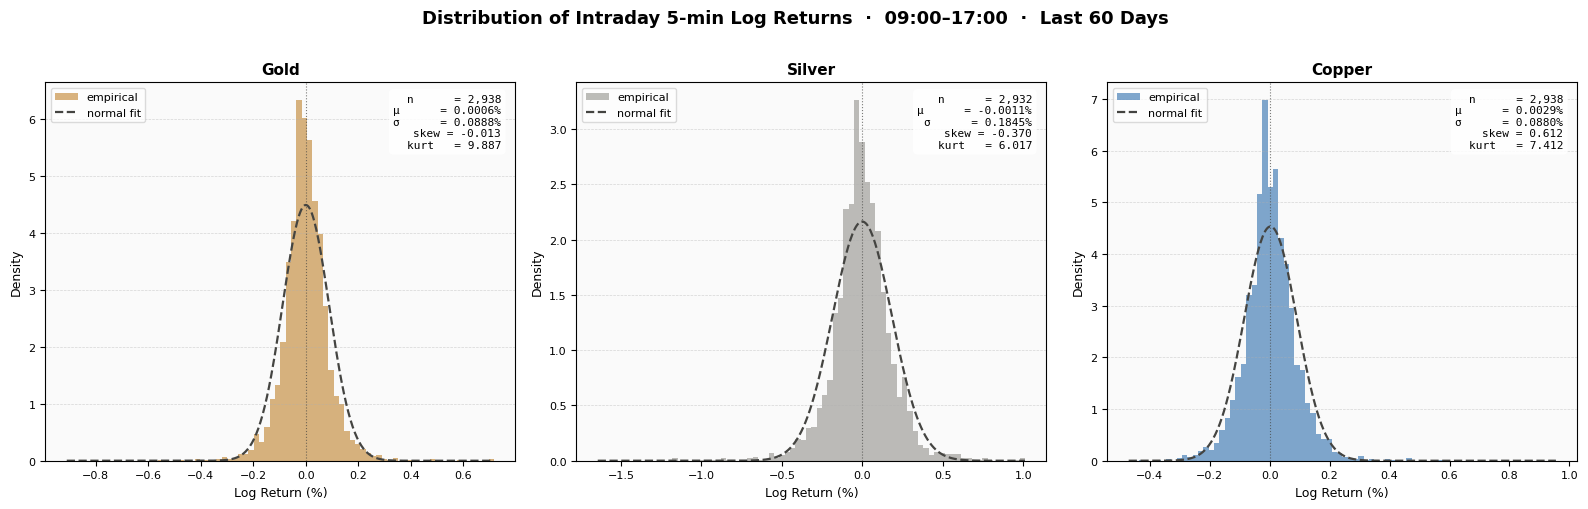

Saved: metals_return_distributions.png


In [13]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution of Intraday 5-min Log Returns  ·  09:00–17:00  ·  Last 60 Days",
             fontsize=13, fontweight="bold", y=1.01)

for ax, (name, (df, color)) in zip(axes, metals.items()):

    # flatten MultiIndex columns if present
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df.index = pd.to_datetime(df.index)

    # filter to session and compute log returns within each day
    session = df.between_time(SESSION_START, SESSION_END)[["Close"]].copy()
    session["log_ret"] = (
        np.log(session["Close"])
        .groupby(session.index.normalize())
        .diff()
    )
    returns = session["log_ret"].dropna().values * 100  # as %

    # --- histogram ---
    ax.hist(returns, bins=80, color=color, alpha=0.55,
            edgecolor="none", density=True, label="empirical")

    # --- normal fit overlay ---
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 400)
    ax.plot(x, norm.pdf(x, mu, sigma),
            color="#444441", linewidth=1.6, linestyle="--",
            label=f"normal fit")

    # --- zero line ---
    ax.axvline(0, color="#444441", linewidth=0.8, linestyle=":", alpha=0.7)

    # --- stats box ---
    kurt = pd.Series(returns).kurt()
    skew = pd.Series(returns).skew()
    stats_txt = (f"n      = {len(returns):,}\n"
                 f"μ      = {mu:.4f}%\n"
                 f"σ      = {sigma:.4f}%\n"
                 f"skew = {skew:.3f}\n"
                 f"kurt   = {kurt:.3f}")
    ax.text(0.97, 0.97, stats_txt,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white",
                      alpha=0.85, ec="none"))

    ax.set_title(name, fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel("Log Return (%)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_facecolor("#fafafa")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.legend(fontsize=8, framealpha=0.7)

fig.tight_layout()
plt.savefig("metals_return_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metals_return_distributions.png")

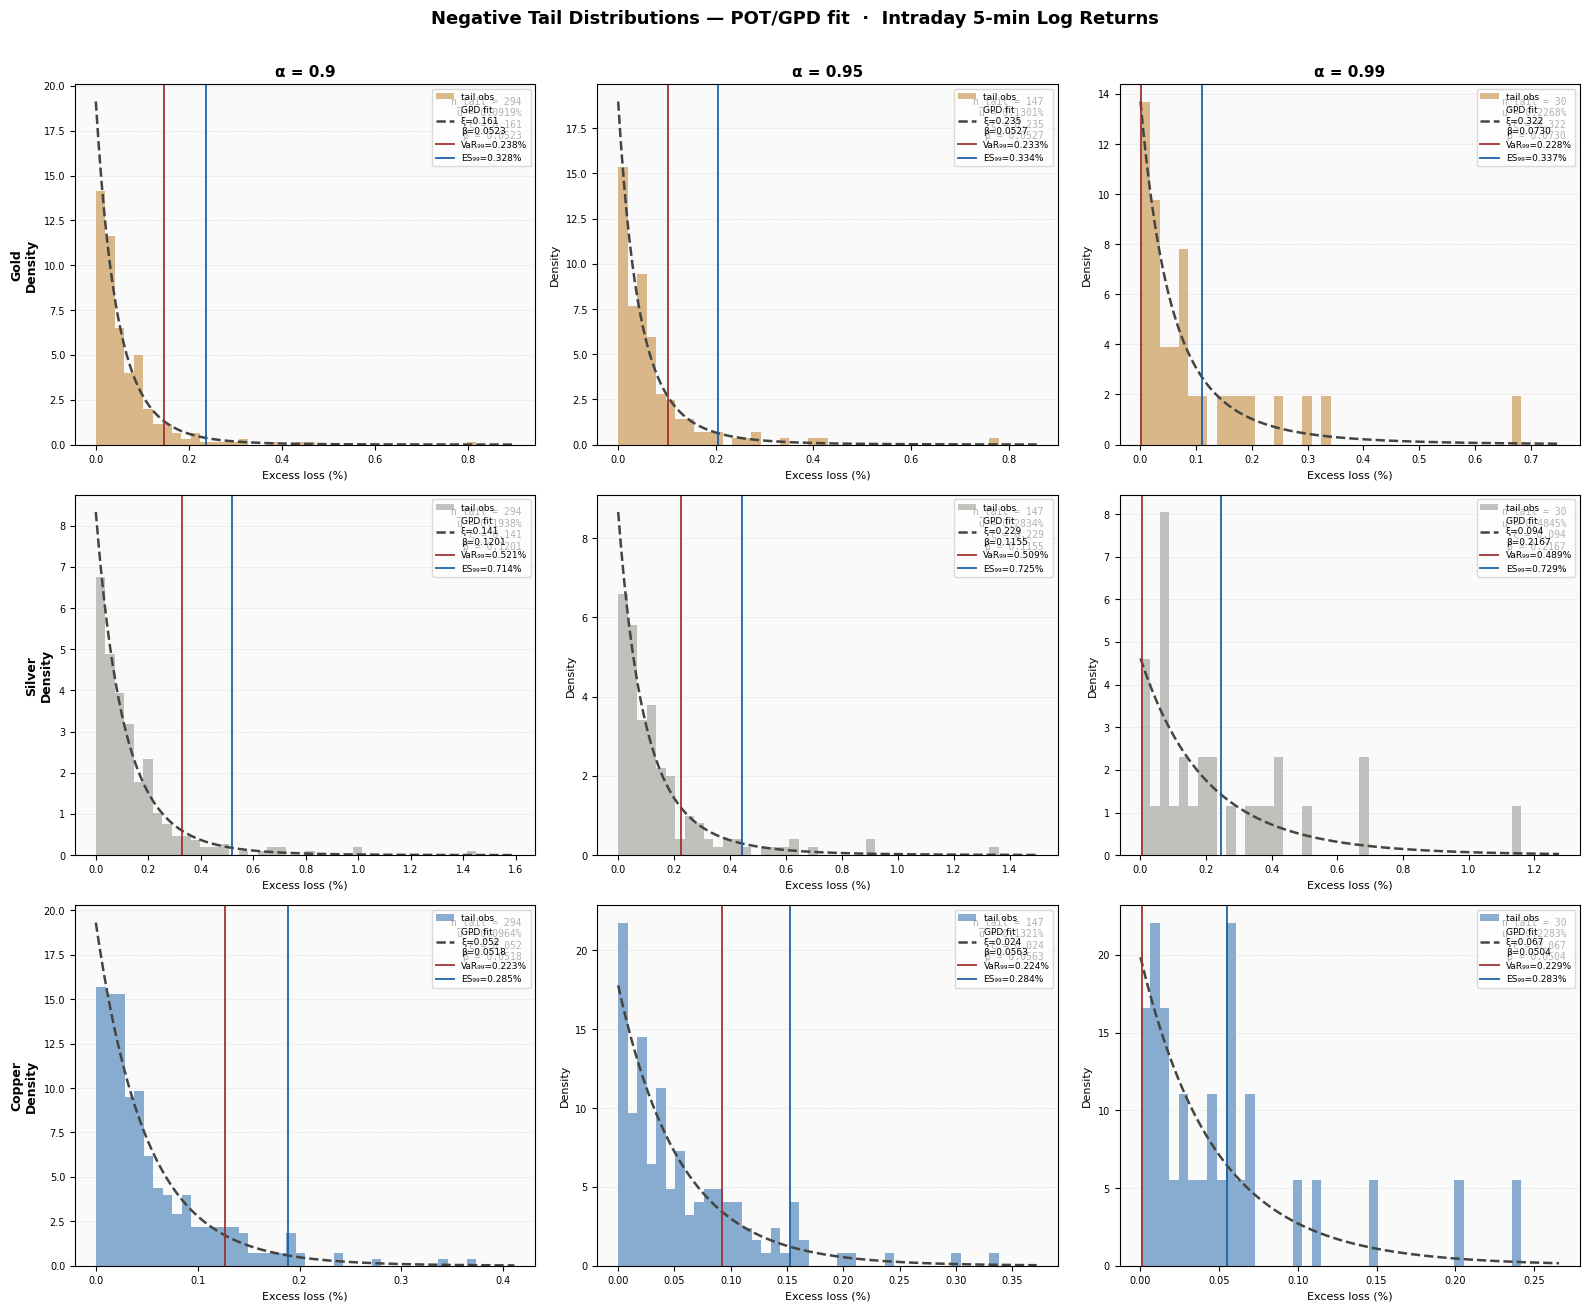

Saved: metals_tail_distributions.png


In [14]:
from scipy.stats import genpareto
from scipy.optimize import minimize

ALPHAS        = [0.90, 0.95, 0.99]

# --- Pre-compute log returns for each metal ---
all_returns = {}
for name, (df, color) in metals.items():
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df.index = pd.to_datetime(df.index)
    session = df.between_time(SESSION_START, SESSION_END)[["Close"]].copy()
    session["log_ret"] = (
        np.log(session["Close"])
        .groupby(session.index.normalize())
        .diff()
    )
    returns = session["log_ret"].dropna().values * 100
    all_returns[name] = returns

# --- GPD fit helper (POT method) ---
def fit_gpd(exceedances):
    """Fit GPD to exceedances via MLE. Returns (xi, beta)."""
    def neg_ll(params):
        xi, beta = params
        if beta <= 0:
            return 1e10
        if abs(xi) < 1e-6:
            return np.sum(np.log(beta) + exceedances / beta)
        inner = 1 + xi * exceedances / beta
        if np.any(inner <= 0):
            return 1e10
        return np.sum(np.log(beta) + (1/xi + 1) * np.log(inner))

    m, v  = exceedances.mean(), exceedances.var()
    xi0   = 0.5 * (1 - m**2 / v) if v > 0 else 0.1
    beta0 = 0.5 * m * (m**2 / v + 1) if v > 0 else m
    res   = minimize(neg_ll, [xi0, beta0], method="Nelder-Mead",
                     options={"xatol":1e-8,"fatol":1e-8,"maxiter":5000})
    return res.x[0], res.x[1]

def gpd_pdf(y, xi, beta):
    if abs(xi) < 1e-6:
        return (1/beta) * np.exp(-y/beta)
    inner = 1 + xi * y / beta
    inner = np.clip(inner, 1e-10, None)
    return (1/beta) * np.power(inner, -1/xi - 1)

# --- Plot ---
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Negative Tail Distributions — POT/GPD fit  ·  Intraday 5-min Log Returns",
             fontsize=13, fontweight="bold", y=1.005)

metal_names = list(metals.keys())
colors      = [v[1] for v in metals.values()]

for row, (name, color) in enumerate(zip(metal_names, colors)):
    returns = all_returns[name]
    # losses = negative returns (flip sign so tail is right-hand side)
    losses = -returns

    for col, alpha in enumerate(ALPHAS):
        ax = axes[row, col]

        # threshold u at alpha quantile of losses
        u          = np.quantile(losses, alpha)
        exceedances = losses[losses > u] - u
        nu          = len(exceedances)
        n           = len(losses)

        if nu < 10:
            ax.text(0.5, 0.5, "Too few obs", transform=ax.transAxes, ha="center")
            continue

        # fit GPD
        xi, beta = fit_gpd(exceedances)

        # histogram of exceedances
        ax.hist(exceedances, bins=40, density=True,
                color=color, alpha=0.50, edgecolor="none", label="tail obs")

        # GPD pdf overlay
        x_max = exceedances.max() * 1.1
        x     = np.linspace(0, x_max, 300)
        ax.plot(x, gpd_pdf(x, xi, beta),
                color="#444441", linewidth=1.8, linestyle="--",
                label=f"GPD fit\nξ={xi:.3f}\nβ={beta:.4f}")

        # VaR and ES lines
        # VaR from eq 5.21
        nu_over_n = nu / n
        if abs(xi) < 1e-6:
            var_exc = -beta * np.log(nu_over_n * (1 - 0.99))
        else:
            var_exc = (beta/xi) * (((1-0.99)/nu_over_n)**(-xi) - 1)
        var_total = u + var_exc

        # ES from eq 5.22
        es_total = var_total/(1-xi) + (beta - xi*u)/(1-xi)

        ax.axvline(var_exc, color="#A32D2D", linewidth=1.4,
                   linestyle="-", alpha=0.9,
                   label=f"VaR₉₉={var_total:.3f}%")
        ax.axvline(es_total - u, color="#185FA5", linewidth=1.4,
                   linestyle="-", alpha=0.9,
                   label=f"ES₉₉={es_total:.3f}%")

        # labels
        if row == 0:
            ax.set_title(f"α = {alpha}", fontsize=11, fontweight="bold", pad=6)
        if col == 0:
            ax.set_ylabel(name.split("(")[0].strip() + "\nDensity",
                          fontsize=9, fontweight="bold")
        else:
            ax.set_ylabel("Density", fontsize=8)

        ax.set_xlabel("Excess loss (%)", fontsize=8)

        # stats box
        stats_txt = (f"n_tail = {nu}\n"
                     f"u = {u:.4f}%\n"
                     f"ξ = {xi:.3f}\n"
                     f"β = {beta:.4f}")
        ax.text(0.97, 0.97, stats_txt,
                transform=ax.transAxes, ha="right", va="top",
                fontsize=7, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          alpha=0.85, ec="none"))

        ax.tick_params(labelsize=7)
        ax.set_facecolor("#fafafa")
        ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4)
        ax.legend(fontsize=6.5, framealpha=0.7, loc="upper right")

fig.tight_layout()
plt.savefig("metals_tail_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metals_tail_distributions.png")

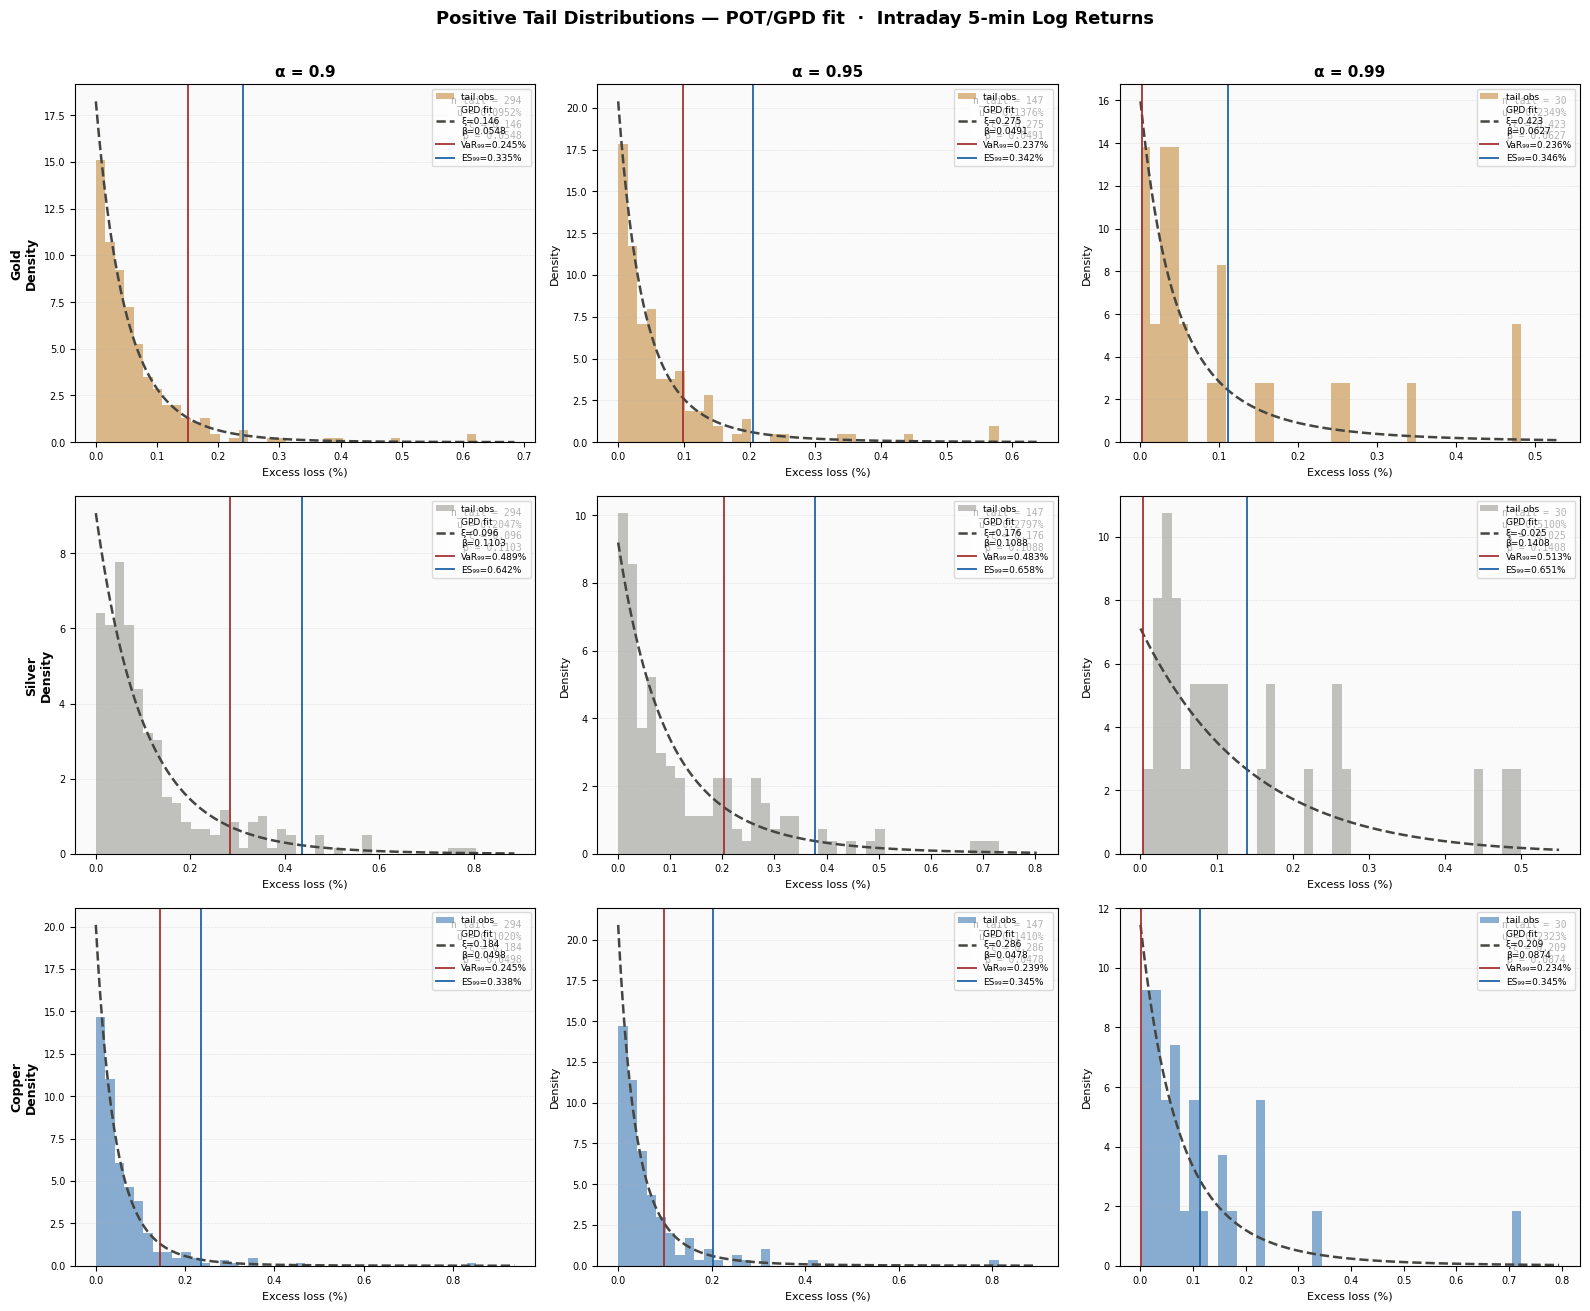

Saved: metals_tail_distributions_gains.png


In [15]:
# --- Plot ---
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Positive Tail Distributions — POT/GPD fit  ·  Intraday 5-min Log Returns",
             fontsize=13, fontweight="bold", y=1.005)

metal_names = list(metals.keys())
colors      = [v[1] for v in metals.values()]

for row, (name, color) in enumerate(zip(metal_names, colors)):
    returns = all_returns[name]
    # gains = positive returns (flip sign so tail is right-hand side)
    # gains = -returns

    for col, alpha in enumerate(ALPHAS):
        ax = axes[row, col]

        # threshold u at alpha quantile of losses
        u          = np.quantile(returns, alpha)
        exceedances = returns[returns > u] - u
        nu          = len(exceedances)
        n           = len(returns)

        if nu < 10:
            ax.text(0.5, 0.5, "Too few obs", transform=ax.transAxes, ha="center")
            continue

        # fit GPD
        xi, beta = fit_gpd(exceedances)

        # histogram of exceedances
        ax.hist(exceedances, bins=40, density=True,
                color=color, alpha=0.50, edgecolor="none", label="tail obs")

        # GPD pdf overlay
        x_max = exceedances.max() * 1.1
        x     = np.linspace(0, x_max, 300)
        ax.plot(x, gpd_pdf(x, xi, beta),
                color="#444441", linewidth=1.8, linestyle="--",
                label=f"GPD fit\nξ={xi:.3f}\nβ={beta:.4f}")

        # VaR and ES lines
        # VaR from eq 5.21
        nu_over_n = nu / n
        if abs(xi) < 1e-6:
            var_exc = -beta * np.log(nu_over_n * (1 - 0.99))
        else:
            var_exc = (beta/xi) * (((1-0.99)/nu_over_n)**(-xi) - 1)
        var_total = u + var_exc

        # ES from eq 5.22
        es_total = var_total/(1-xi) + (beta - xi*u)/(1-xi)

        ax.axvline(var_exc, color="#A32D2D", linewidth=1.4,
                   linestyle="-", alpha=0.9,
                   label=f"VaR₉₉={var_total:.3f}%")
        ax.axvline(es_total - u, color="#185FA5", linewidth=1.4,
                   linestyle="-", alpha=0.9,
                   label=f"ES₉₉={es_total:.3f}%")

        # labels
        if row == 0:
            ax.set_title(f"α = {alpha}", fontsize=11, fontweight="bold", pad=6)
        if col == 0:
            ax.set_ylabel(name.split("(")[0].strip() + "\nDensity",
                          fontsize=9, fontweight="bold")
        else:
            ax.set_ylabel("Density", fontsize=8)

        ax.set_xlabel("Excess loss (%)", fontsize=8)

        # stats box
        stats_txt = (f"n_tail = {nu}\n"
                     f"u = {u:.4f}%\n"
                     f"ξ = {xi:.3f}\n"
                     f"β = {beta:.4f}")
        ax.text(0.97, 0.97, stats_txt,
                transform=ax.transAxes, ha="right", va="top",
                fontsize=7, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          alpha=0.85, ec="none"))

        ax.tick_params(labelsize=7)
        ax.set_facecolor("#fafafa")
        ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4)
        ax.legend(fontsize=6.5, framealpha=0.7, loc="upper right")

fig.tight_layout()
plt.savefig("metals_tail_distributions_gains.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metals_tail_distributions_gains.png")

In [16]:
import warnings
import itertools
from arch import arch_model
from hmmlearn import hmm

warnings.filterwarnings("ignore")


# ── 1. GARCH — BIC grid search over p, q ─────────────────────────────────────
def fit_garch_bic(returns, p_range=range(1, 4), q_range=range(1, 4)):
    """
    Fit GARCH(p,q) with Student-t innovations for all (p,q) combinations.
    Select the best model by BIC.
    Returns the best fitted model and a summary DataFrame.
    """
    results = []
    for p, q in itertools.product(p_range, q_range):
        try:
            m = arch_model(returns, mean="AR", lags=1,
                           vol="GARCH", p=p, q=q,
                           dist="t")
            fit = m.fit(disp="off", options={"maxiter": 500})
            results.append({
                "p": p, "q": q,
                "loglik": fit.loglikelihood,
                "nparams": fit.num_params,
                "aic": fit.aic,
                "bic": fit.bic,
                "fit": fit,
            })
        except Exception:
            pass

    summary = pd.DataFrame(results).drop(columns="fit")
    best_row = min(results, key=lambda x: x["bic"])
    return best_row["fit"], best_row["p"], best_row["q"], summary


In [17]:
# ── 2. MS-GARCH — BIC selection over number of regimes ────────────────────────
def fit_msgarch_bic(returns, regime_range=range(2, 5)):
    """
    Approximate MS-GARCH using a Gaussian HMM on squared returns as the
    observable proxy for volatility.  For each number of regimes K:
      - fit a GaussianHMM(K) on the return series
      - decode the most likely state sequence
      - fit a separate GARCH(1,1) per regime on the state-filtered returns
      - compute a composite BIC

    Returns: best K, state sequence, per-regime GARCH fits, BIC summary.
    """
    returns = pd.Series(np.array(returns).flatten())  # ← normalise input type
    X = returns.values.reshape(-1, 1)

    results = []
    for k in regime_range:
        try:
            model = hmm.GaussianHMM(
                n_components=k,
                covariance_type="full",
                n_iter=200,
                random_state=42,
            )
            model.fit(X)
            log_prob = model.score(X)
            n_params  = k * k + k + k   # transition + means + variances (approx)
            n         = len(returns)
            bic       = -2 * log_prob + n_params * np.log(n)
            states    = model.predict(X)
            results.append({
                "K": k,
                "log_prob": log_prob,
                "n_params": n_params,
                "bic": bic,
                "model": model,
                "states": states,
            })
        except Exception:
            pass

    summary = pd.DataFrame([{k: v for k, v in r.items()
                              if k not in ("model","states")}
                             for r in results])

    best = min(results, key=lambda x: x["bic"])

    # fit GARCH(1,1)-t per regime on the best K solution
    regime_fits = {}
    for k in range(best["K"]):
        idx = np.where(best["states"] == k)[0]
        if len(idx) < 50:
            continue
        r_k = returns.iloc[idx]
        try:
            m = arch_model(r_k, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
            regime_fits[k] = m.fit(disp="off", options={"maxiter": 500})
        except Exception:
            pass

    return best["K"], best["states"], regime_fits, best["model"], summary

In [18]:
print("=" * 65)
print("GARCH & MS-GARCH MODEL SELECTION — BIC")
print("=" * 65)

all_results = {}

for metal_name, raw_df in metals.items():
    print(f"\n{'─'*65}")
    print(f"  {metal_name}")
    print(f"{'─'*65}")

#     returns = get_returns(raw_df) 
    print(f"  Observations : {len(all_returns[metal_name]):,}")
    print(f"  Mean         : {all_returns[metal_name].mean():.5f}%")
    print(f"  Std          : {all_returns[metal_name].std():.5f}%")

    # ── GARCH ──
    print("\n  [1] GARCH(p,q) — BIC grid search (p,q ∈ 1..3)")
    best_garch, best_p, best_q, garch_bic_table = fit_garch_bic(all_returns[metal_name])

    print(f"\n  BIC table:")
    print(garch_bic_table[["p","q","loglik","nparams","aic","bic"]]
          .sort_values("bic")
          .to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    print(f"\n  ✓ Best GARCH : ({best_p},{best_q})  "
          f"BIC={best_garch.bic:.2f}  "
          f"AIC={best_garch.aic:.2f}")
    print(f"\n  Parameter estimates:")
    print(best_garch.params.to_string())
    print(f"\n  Persistence (α+β) : "
          f"{best_garch.params.get('alpha[1]',0) + best_garch.params.get('beta[1]',0):.4f}")

    # ── MS-GARCH ──
    print("\n  [2] MS-GARCH — BIC selection over K regimes (K=2,3,4)")
    best_K, states, regime_fits, hmm_model, ms_bic_table = fit_msgarch_bic(all_returns[metal_name])

    print(f"\n  BIC table:")
    print(ms_bic_table[["K","log_prob","n_params","bic"]]
          .sort_values("bic")
          .to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    print(f"\n  ✓ Best MS-GARCH : K={best_K} regimes")

    print(f"\n  Regime summary:")

    returns_s = pd.Series(np.array(returns).flatten())
    for k in range(best_K):
        idx   = np.where(states == k)[0]
        r_k   = returns_s.iloc[idx]

#     for k in range(best_K):
#         idx   = np.where(states == k)[0]
#         r_k   = returns.iloc[idx]
        label = f"  Regime {k+1}"
        print(f"{label}:  n={len(idx):5d}  "
              f"({100*len(idx)/len(returns):.1f}%)  "
              f"mean={r_k.mean():.4f}%  "
              f"vol={r_k.std():.4f}%")
        if k in regime_fits:
            p = regime_fits[k].params
            a = p.get("alpha[1]", 0)
            b = p.get("beta[1]", 0)
            print(f"           GARCH(1,1):  ω={p.get('omega',0):.6f}  "
                  f"α={a:.4f}  β={b:.4f}  "
                  f"persistence={a+b:.4f}")

    all_results[metal_name] = {
        "returns":      returns,
        "garch":        best_garch,
        "garch_p":      best_p,
        "garch_q":      best_q,
        "msgarch_K":    best_K,
        "msgarch_states": states,
        "msgarch_regime_fits": regime_fits,
        "msgarch_hmm":  hmm_model,
    }

print(f"\n{'='*65}")
print("Done. Results stored in all_results dict for downstream use.")
print("  all_results[metal]['garch']          → best GARCH fit")
print("  all_results[metal]['msgarch_states'] → regime labels per obs")
print("  all_results[metal]['msgarch_regime_fits'] → per-regime GARCH")
print(f"{'='*65}")

GARCH & MS-GARCH MODEL SELECTION — BIC

─────────────────────────────────────────────────────────────────
  Gold
─────────────────────────────────────────────────────────────────
  Observations : 2,938
  Mean         : 0.00059%
  Std          : 0.08884%

  [1] GARCH(p,q) — BIC grid search (p,q ∈ 1..3)

  BIC table:
 p  q  loglik  nparams      aic      bic
 1  1 3346.06        6 -6680.11 -6644.20
 2  2 3346.39        8 -6676.78 -6628.90
 1  2 3342.07        7 -6670.14 -6628.25
 3  1 3346.06        8 -6676.11 -6628.23
 2  3 3346.98        9 -6675.97 -6622.10
 1  3 3342.84        8 -6669.67 -6621.79
 2  1 3337.62        7 -6661.23 -6619.34
 3  2 3332.69        9 -6647.38 -6593.51
 3  3 3334.10       10 -6648.19 -6588.34

  ✓ Best GARCH : (1,1)  BIC=-6644.20  AIC=-6680.11

  Parameter estimates:
Const      -0.000761
y[1]       -0.039908
omega       0.000532
alpha[1]    0.120658
beta[1]     0.812848
nu          4.658250

  Persistence (α+β) : 0.9335

  [2] MS-GARCH — BIC selection over K re

## Predicted Volatilities vs Actual Volatilities

In [19]:
import json
import numpy as np

def to_serialisable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (pd.Timestamp, datetime.datetime)):
        return str(obj)
    return obj


  Gold  GARCH(1,1)
    Rolling forecast: 2438 steps ... done

  Silver  GARCH(1,1)
    Rolling forecast: 2432 steps ... done

  Copper  GARCH(1,1)
    Rolling forecast: 2438 steps ... done


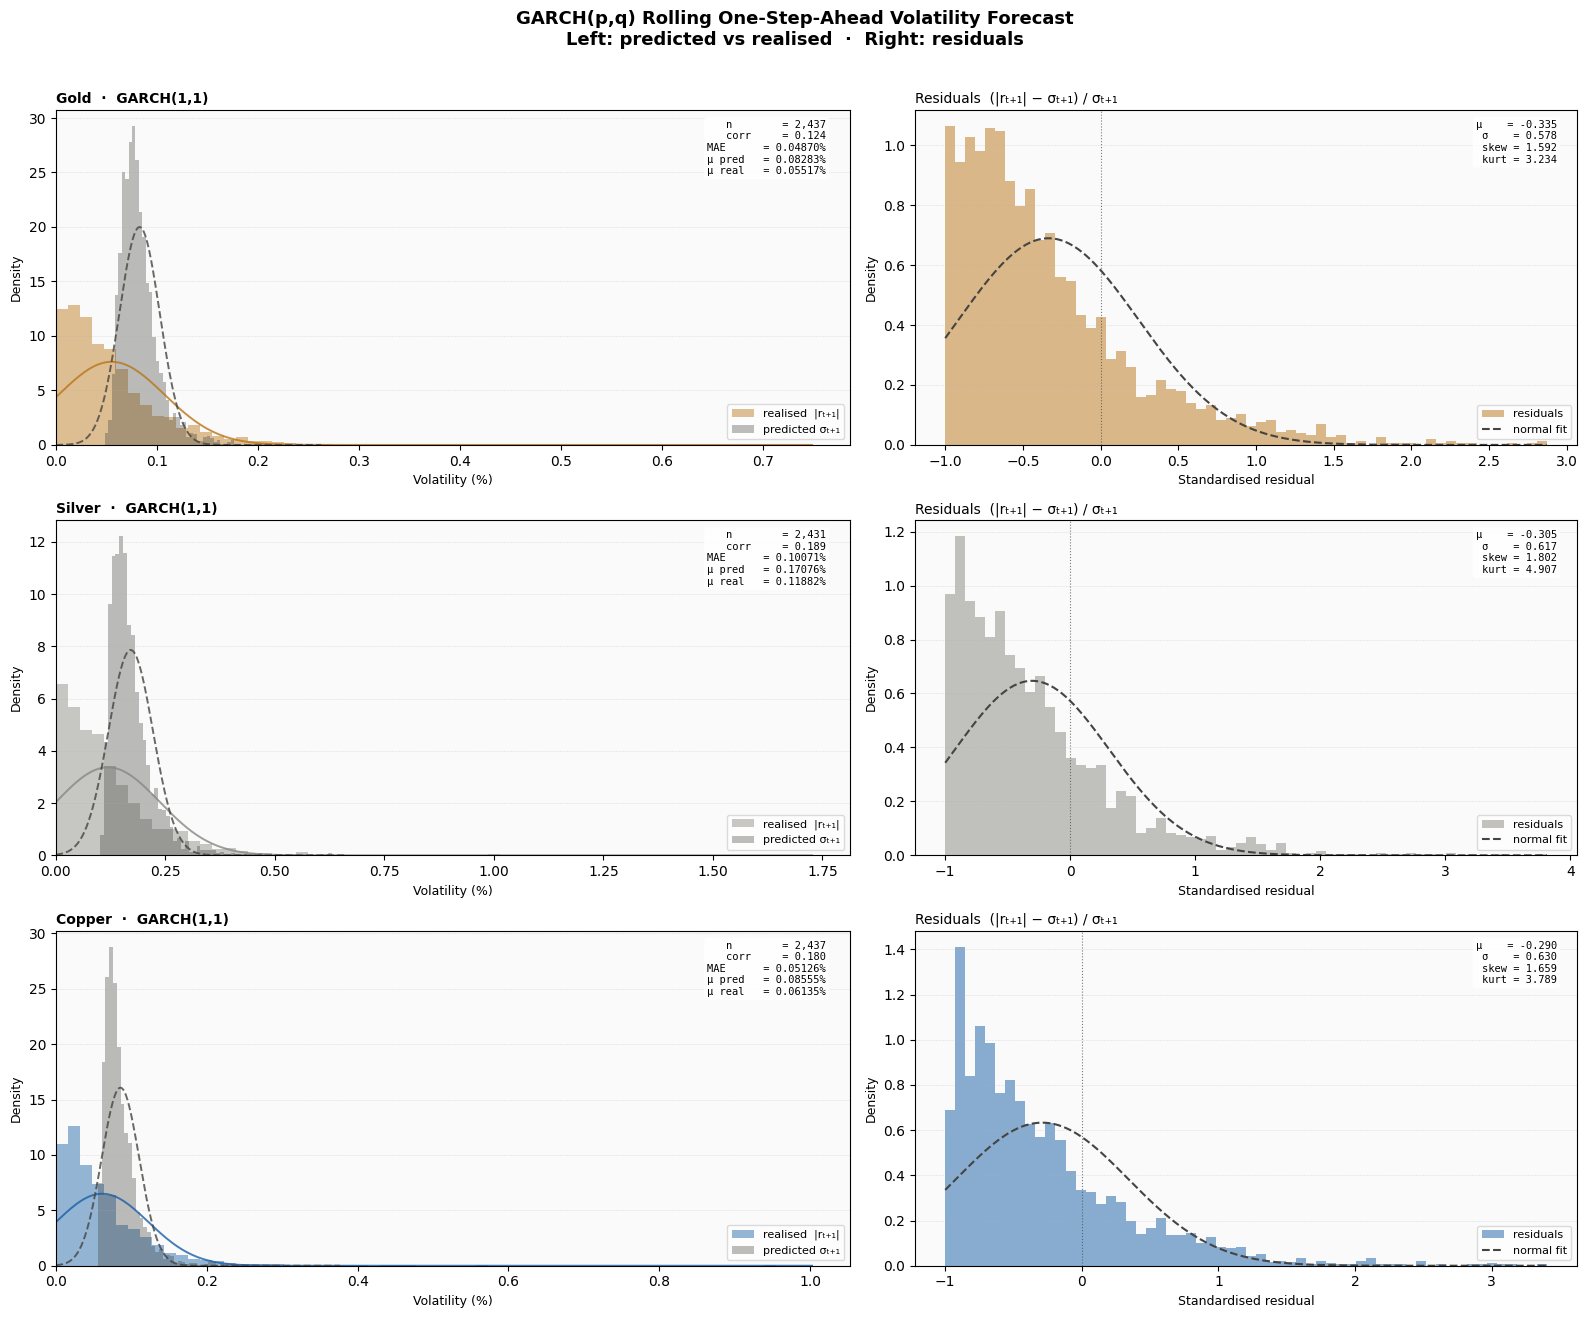


Saved: garch_vol_forecast_vs_realised.png
Saved: garch_forecasts.json


In [20]:
# ── Best GARCH orders from previous BIC selection ────────────────────────────

BEST_ORDERS = {
    "Gold":   (1, 1),
    "Silver": (1, 1),
    "Copper": (1, 1),
}

# ── Rolling one-step-ahead volatility forecast ────────────────────────────────
def rolling_vol_forecast(returns, p, q, min_train=500):
    """
    For each t from min_train to T-1:
      - fit GARCH(p,q)-t on returns[0:t]
      - forecast σ_{t+1} (one-step-ahead)
    Returns:
      pred_vol  : predicted σ_{t+1}  (annualised-equivalent %)
      real_vol  : |r_{t+1}|          (realised absolute return as vol proxy)
      residuals : (|r_{t+1}| - σ_{t+1}) / σ_{t+1}   (standardised)
      index     : timestamps of the forecast points
    """
    r = np.array(returns)
    T = len(r)

    pred_vol  = []
    real_vol  = []
    idx       = []

    print(f"    Rolling forecast: {T - min_train} steps ... ", end="", flush=True)

    for t in range(min_train, T - 1):
        try:
            m   = arch_model(r[:t], mean="AR", lags=1,
                             vol="GARCH", p=p, q=q, dist="t")
            fit = m.fit(disp="off", options={"maxiter": 300})
            fc  = fit.forecast(horizon=1, reindex=False)
            sigma_next = np.sqrt(fc.variance.values[-1, 0])   # σ_{t+1}

            pred_vol.append(sigma_next)
            real_vol.append(abs(r[t + 1]))                    # |r_{t+1}|
            idx.append(returns.index[t + 1])
        except Exception:
            continue

    print("done")

    pred_vol  = np.array(pred_vol)
    real_vol  = np.array(real_vol)
    residuals = (real_vol - pred_vol) / pred_vol              # relative error

    return pred_vol, real_vol, residuals, idx


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 13),
                         gridspec_kw={"width_ratios": [1.2, 1]})
fig.suptitle("GARCH(p,q) Rolling One-Step-Ahead Volatility Forecast\n"
             "Left: predicted vs realised  ·  Right: residuals",
             fontsize=13, fontweight="bold", y=1.01)

pred_vols = {}
real_vols = {}
residualss = {}
idxs = {}

for row, (name, (df, color)) in enumerate(metals.items()):
    p, q = BEST_ORDERS[name]
    print(f"\n  {name}  GARCH({p},{q})")

    # returns = get_returns(df)

    pred_vol, real_vol, residuals, idx = rolling_vol_forecast(all_returns[name], p, q)

    pred_vols[name] = pred_vol
    real_vols[name] = real_vol
    residualss[name] = residuals
    idxs[name] = idx

    ax_dist = axes[row, 0]
    ax_res  = axes[row, 1]

    # ── Left: predicted vs realised distributions ─────────────────────────
    bins = 60
    ax_dist.hist(real_vol, bins=bins, density=True,
                 color=color, alpha=0.45, edgecolor="none",
                 label="realised  |rₜ₊₁|")
    ax_dist.hist(pred_vol, bins=bins, density=True,
                 color="#444441", alpha=0.35, edgecolor="none",
                 label="predicted σₜ₊₁")

    # normal overlays
    for vals, c, ls in [(real_vol, color, "-"), (pred_vol, "#444441", "--")]:
        mu_v, s_v = vals.mean(), vals.std()
        x = np.linspace(0, vals.max() * 1.05, 300)
        ax_dist.plot(x, norm.pdf(x, mu_v, s_v),
                     color=c, linewidth=1.4, linestyle=ls, alpha=0.8)

    # stats annotation
    corr = np.corrcoef(pred_vol, real_vol)[0, 1]
    mae  = np.mean(np.abs(real_vol - pred_vol))
    txt  = (f"n        = {len(pred_vol):,}\n"
            f"corr     = {corr:.3f}\n"
            f"MAE      = {mae:.5f}%\n"
            f"μ pred   = {pred_vol.mean():.5f}%\n"
            f"μ real   = {real_vol.mean():.5f}%")
    ax_dist.text(0.97, 0.97, txt,
                 transform=ax_dist.transAxes, ha="right", va="top",
                 fontsize=7.5, family="monospace",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white",
                           alpha=0.85, ec="none"))

    ax_dist.set_title(f"{name}  ·  GARCH({p},{q})",
                      fontsize=10, fontweight="bold", loc="left", pad=5)
    ax_dist.set_xlabel("Volatility (%)", fontsize=9)
    ax_dist.set_ylabel("Density", fontsize=9)
    ax_dist.legend(fontsize=8, framealpha=0.7)
    ax_dist.set_facecolor("#fafafa")
    ax_dist.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4)
    ax_dist.set_xlim(left=0)

    # ── Right: residual distribution ──────────────────────────────────────
    # clip extreme outliers for display (keep 99.5% of data)
    lo, hi = np.percentile(residuals, 0.25), np.percentile(residuals, 99.75)
    res_clipped = residuals[(residuals >= lo) & (residuals <= hi)]

    ax_res.hist(res_clipped, bins=60, density=True,
                color=color, alpha=0.50, edgecolor="none",
                label="residuals")

    # normal fit
    mu_r, s_r = res_clipped.mean(), res_clipped.std()
    x = np.linspace(res_clipped.min(), res_clipped.max(), 300)
    ax_res.plot(x, norm.pdf(x, mu_r, s_r),
                color="#444441", linewidth=1.5, linestyle="--",
                label="normal fit")

    ax_res.axvline(0, color="#444441", linewidth=0.8,
                   linestyle=":", alpha=0.7)

    # stats
    kurt = pd.Series(res_clipped).kurt()
    skew = pd.Series(res_clipped).skew()
    txt2 = (f"μ    = {mu_r:.3f}\n"
            f"σ    = {s_r:.3f}\n"
            f"skew = {skew:.3f}\n"
            f"kurt = {kurt:.3f}")
    ax_res.text(0.97, 0.97, txt2,
                transform=ax_res.transAxes, ha="right", va="top",
                fontsize=7.5, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          alpha=0.85, ec="none"))

    ax_res.set_title("Residuals  (|rₜ₊₁| − σₜ₊₁) / σₜ₊₁",
                     fontsize=10, loc="left", pad=5)
    ax_res.set_xlabel("Standardised residual", fontsize=9)
    ax_res.set_ylabel("Density", fontsize=9)
    ax_res.legend(fontsize=8, framealpha=0.7)
    ax_res.set_facecolor("#fafafa")
    ax_res.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4)

fig.tight_layout()
plt.savefig("garch_vol_forecast_vs_realised.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: garch_vol_forecast_vs_realised.png")



payload = {}
for name in metals:
    payload[name] = {
        "pred_vol":  pred_vols[name].tolist(),
        "real_vol":  real_vols[name].tolist(),
        "residuals": residualss[name].tolist(),
        "idx":       [str(i) for i in idxs[name]],
    }

with open("garch_forecasts.json", "w") as f:
    json.dump(payload, f, indent=2)

print("Saved: garch_forecasts.json")

In [ ]:
# Load 
with open("garch_forecasts.json", "r") as f:
    loaded = json.load(f)

pred_vols  = {}
real_vols  = {}
residualss = {}
idxs       = {}

for name, data in loaded.items():
    pred_vols[name]  = np.array(data["pred_vol"])
    real_vols[name]  = np.array(data["real_vol"])
    residualss[name] = np.array(data["residuals"])
    idxs[name]       = pd.to_datetime(data["idx"])

In [22]:
# ── Helper: session log returns ───────────────────────────────────────────────
def get_returns(df):
    df = df.copy()
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df.index = pd.to_datetime(df.index)
    session = df.between_time(SESSION_START, SESSION_END)[["Close"]].copy()
    session["log_ret"] = (
        np.log(session["Close"])
        .groupby(session.index.normalize())
        .diff()
    )
    return session["log_ret"].dropna() * 100

In [21]:
# ── Rolling forecast returning full series ────────────────────────────────────
def rolling_forecast(returns, p, q, min_train=500):
    r   = np.array(returns)
    T   = len(r)
    out = []
 
    print(f"    Forecasting {T - min_train} steps ... ", end="", flush=True)
    for t in range(min_train, T - 1):
        try:
            m   = arch_model(r[:t], mean="AR", lags=1,
                             vol="GARCH", p=p, q=q, dist="t")
            fit = m.fit(disp="off", options={"maxiter": 300})
            fc  = fit.forecast(horizon=1, reindex=False)
            sigma_next = np.sqrt(fc.variance.values[-1, 0])
            out.append({
                "timestamp": returns.index[t + 1],
                "actual":    r[t + 1],
                "pred_sigma": sigma_next,
            })
        except Exception:
            continue
 
    print("done")
    return pd.DataFrame(out).set_index("timestamp")

In [44]:
metals_meta = {
    "Gold":   (gold,   "#BA7517"),
    "Silver": (silver, "#888780"),
    "Copper": (copper, "#185FA5"),
}

BEST_ORDERS = {
    "Gold":   (1, 1),
    "Silver": (1, 1),
    "Copper": (1, 1),
}
 
BANDS = {
    "1σ (68%)": 1.0,
    "2σ (95%)": 2.0,
    "3σ (99%)": 3.0,
}

GARCH VOLATILITY BANDS — HIT/MISS ANALYSIS


HIT / MISS TABLE
 Metal     Band  Total  Hits  Misses  Hit %
  Gold 1σ (68%)   2437  1902     535  78.05
  Gold 2σ (95%)   2437  2337     100  95.90
  Gold 3σ (99%)   2437  2418      19  99.22
Silver 1σ (68%)   2431  1862     569  76.59
Silver 2σ (95%)   2431  2321     110  95.48
Silver 3σ (99%)   2431  2407      24  99.01
Copper 1σ (68%)   2437  1848     589  75.83
Copper 2σ (95%)   2437  2321     116  95.24
Copper 3σ (99%)   2437  2405      32  98.69


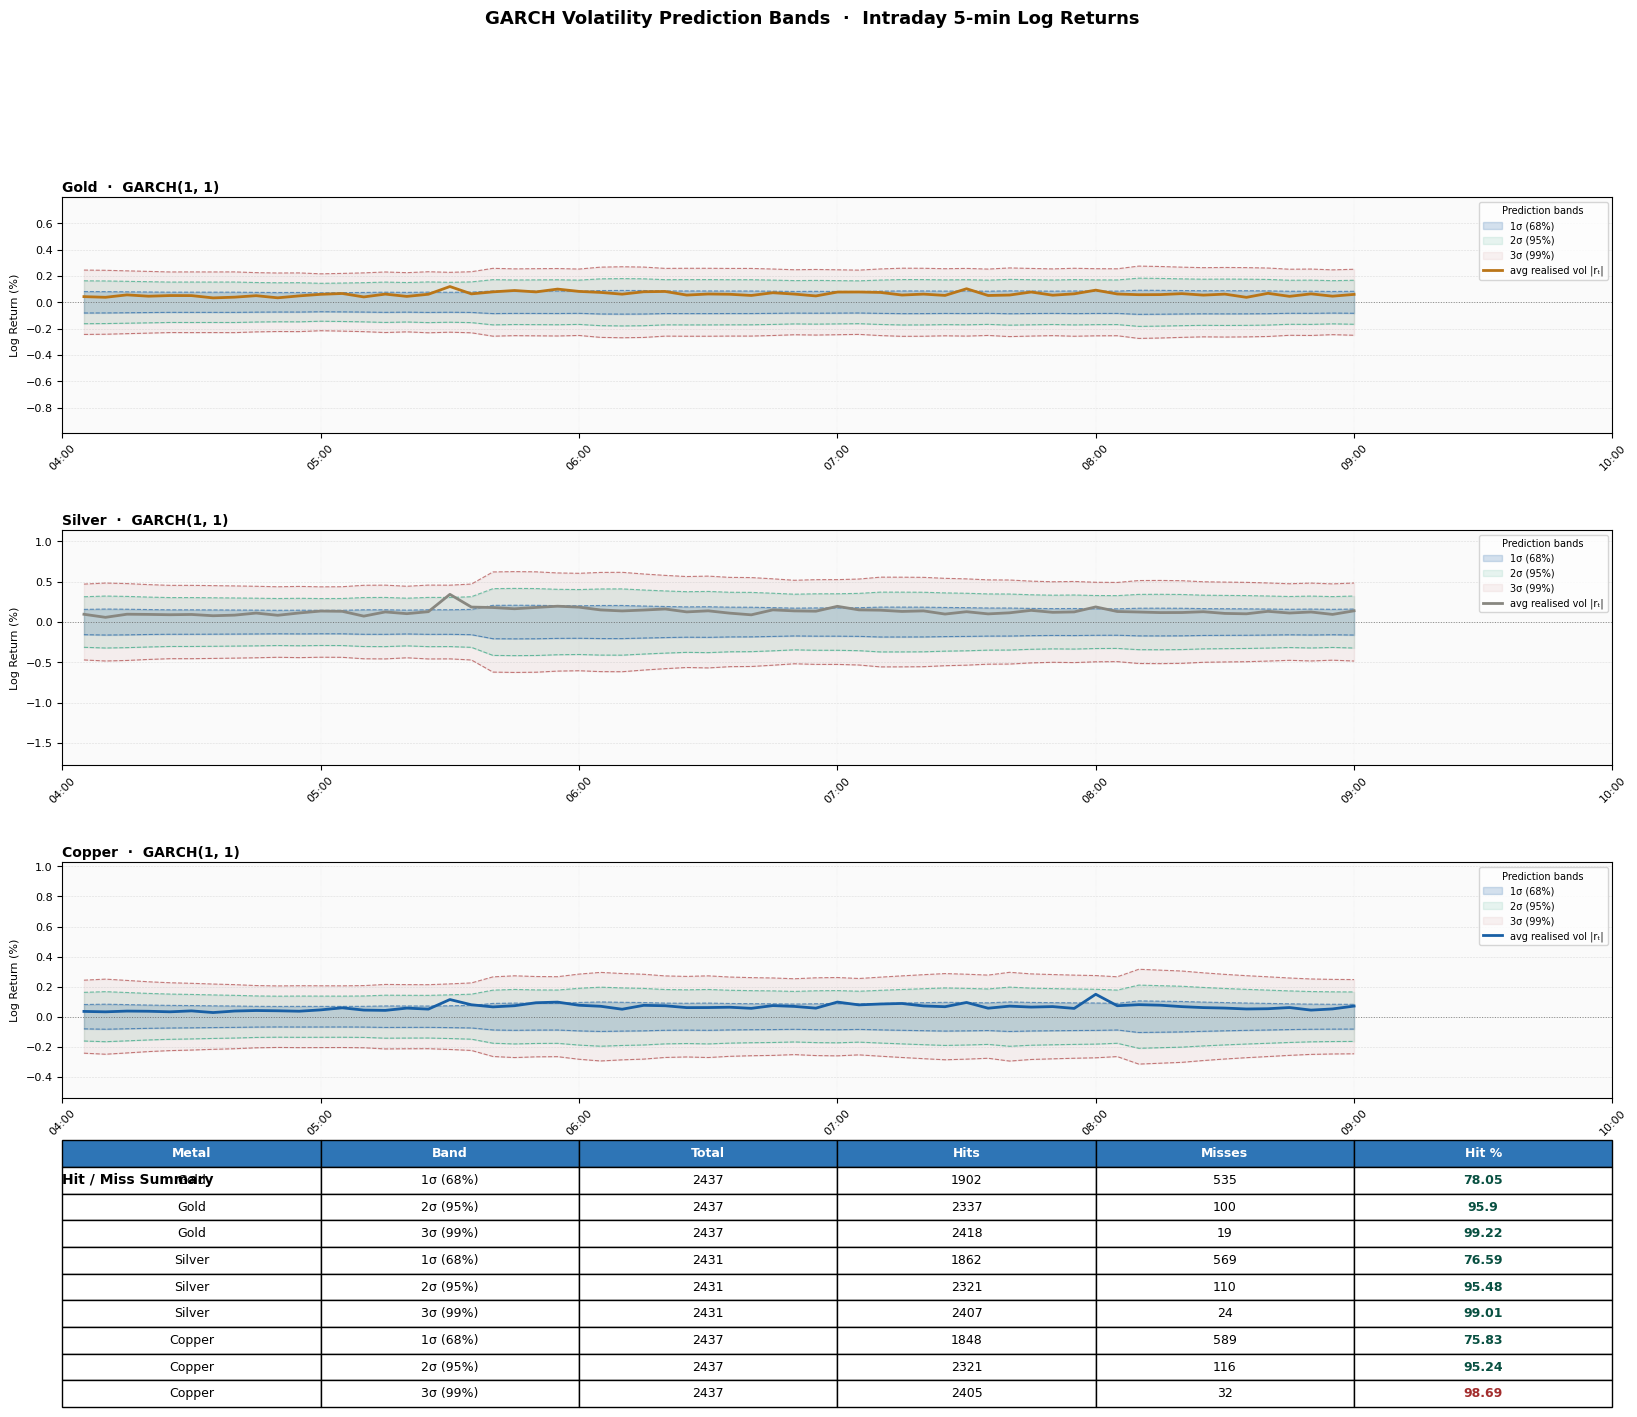


Saved: garch_bands_hitmiss.png


In [53]:
# ── Hit/miss using actual returns from get_returns ────────────────────────────
print("=" * 60)
print("GARCH VOLATILITY BANDS — HIT/MISS ANALYSIS")
print("=" * 60)
 
all_fc       = {}
summary_rows = []
 
for name, (df, color) in metals_meta.items():
    returns = get_returns(df)

    # align actual returns to forecast positions by index
    pred_s  = pd.Series(pred_vols[name], index=returns.index[-len(pred_vols[name]):])
    actual_s = returns.reindex(pred_s.index)

    fc_df = pd.DataFrame({
        "actual":     actual_s.values,
        "pred_sigma": pred_s.values,
    }, index=pred_s.index)
    all_fc[name] = (fc_df, color)
 
    for band_label, mult in BANDS.items():
        upper  =  fc_df["pred_sigma"] * mult
        lower  = -fc_df["pred_sigma"] * mult
        inside = (fc_df["actual"] >= lower) & (fc_df["actual"] <= upper)
        n_total = len(inside)
        n_hit   = inside.sum()
        summary_rows.append({
            "Metal":  name,
            "Band":   band_label,
            "Total":  n_total,
            "Hits":   n_hit,
            "Misses": n_total - n_hit,
            "Hit %":  round(100 * n_hit / n_total, 2),
        })
 
summary = pd.DataFrame(summary_rows)
print("\n")
print("=" * 60)
print("HIT / MISS TABLE")
print("=" * 60)
print(summary.to_string(index=False))
print("=" * 60)
 
# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 15))
fig.suptitle("GARCH Volatility Prediction Bands  ·  Intraday 5-min Log Returns",
             fontsize=13, fontweight="bold", y=1.005)
 
gs = fig.add_gridspec(4, 1, height_ratios=[3, 3, 3, 2], hspace=0.45)
 
for row, (name, (fc_df, color)) in enumerate(all_fc.items()):
    ax = fig.add_subplot(gs[row])
 
    returns_full = get_returns(metals_meta[name][0])
    dates = returns_full.index.normalize().unique()
 
    for i, day in enumerate(dates):
        day_data = returns_full[returns_full.index.normalize() == day]
        if len(day_data) < 2:
            continue
        times = [t.replace(year=2000, month=1, day=1) for t in day_data.index]
        alpha = 0.15 + 0.40 * (i / max(len(dates) - 1, 1))
        ax.plot(times, day_data.values, color=color,
                linewidth=0.6, alpha=alpha)
 

    fc_df["time_key"] = pd.to_datetime(fc_df.index).map(
        lambda t: t.tz_localize(None).replace(year=2026, month=6, day=3)
        if t.tzinfo is not None
        else t.replace(year=2000, month=1, day=1)
    )
    avg_sigma = fc_df.groupby("time_key")["pred_sigma"].mean()

    # average absolute return (realised vol proxy) per time-of-day
    abs_returns = returns_full.abs().copy()
    abs_returns.index = abs_returns.index.map(
        lambda t: t.tz_localize(None).replace(year=2026, month=6, day=3)
        if hasattr(t, 'tzinfo') and t.tzinfo is not None
        else t.replace(year=2000, month=1, day=1)
    )
    avg_realised_vol = abs_returns.groupby(abs_returns.index).mean().dropna()

 
    band_styles = [("1σ (68%)", 1.0, 0.18),
                   ("2σ (95%)", 2.0, 0.10),
                   ("3σ (99%)", 3.0, 0.06)]
    band_colors = ["#185FA5", "#1D9E75", "#A32D2D"]
 
    for (label, mult, alpha_fill), bc in zip(band_styles, band_colors):
        ax.fill_between(avg_sigma.index,
                        -avg_sigma * mult,
                         avg_sigma * mult,
                        color=bc, alpha=alpha_fill, label=label)
        ax.plot(avg_sigma.index,  avg_sigma * mult,
                color=bc, linewidth=0.8, linestyle="--", alpha=0.6)
        ax.plot(avg_sigma.index, -avg_sigma * mult,
                color=bc, linewidth=0.8, linestyle="--", alpha=0.6)
    
    ax.plot(avg_realised_vol.index, avg_realised_vol.values,
            color=color, linewidth=2.0, linestyle="-",
            zorder=11, label="avg realised vol |rₜ|")
    ax.axhline(0, color="#444441", linewidth=0.7, linestyle=":", alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(REF_DATE.replace(hour=4,  minute=0),
                REF_DATE.replace(hour=10, minute=0))
    ax.set_title(f"{name}  ·  GARCH{BEST_ORDERS[name]}",
                 fontsize=10, fontweight="bold", loc="left", pad=4)
    ax.set_ylabel("Log Return (%)", fontsize=8)
    ax.set_facecolor("#fafafa")
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.4)
    ax.grid(axis="x", linestyle=":",  linewidth=0.3, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right", framealpha=0.8,
              title="Prediction bands", title_fontsize=7)
 
# ── Table panel ───────────────────────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs[3])
ax_tbl.axis("off")
 
col_labels = ["Metal", "Band", "Total", "Hits", "Misses", "Hit %"]
cell_text  = summary[col_labels].values.tolist()
 
tbl = ax_tbl.table(cellText=cell_text, colLabels=col_labels,
                   loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
 
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor("#2E75B6")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
 
metal_colors_tbl = {
    "Gold (GC=F)":   "#FAEEDA",
    "Silver (SI=F)": "#F1EFE8",
    "Copper (HG=F)": "#E6F1FB",
}
for i, row_data in enumerate(cell_text):
    bg = metal_colors_tbl.get(row_data[0], "#FFFFFF")
    for j in range(len(col_labels)):
        tbl[i + 1, j].set_facecolor(bg)
        if col_labels[j] == "Hit %":
            pct_val  = float(row_data[j])
            expected = {"1σ (68%)": 68, "2σ (95%)": 95, "3σ (99%)": 99}
            exp      = expected.get(row_data[1], 95)
            tbl[i + 1, j].set_text_props(
                color="#085041" if pct_val >= exp else "#A32D2D",
                fontweight="bold"
            )
 
ax_tbl.set_title("Hit / Miss Summary", fontsize=10,
                 fontweight="bold", loc="left", pad=8)
 
plt.savefig("garch_bands_hitmiss.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: garch_bands_hitmiss.png")

## AR-GARCH